# Day 3: Exploratory Analysis & Baseline Model

## Objective
Understand price behavior and build a first model for property price prediction in Kenya.

### Key Questions to Answer:
1. Which locations are most expensive?
2. How strongly does size affect price?
3. Which amenities increase value?

### Modeling Steps:
1. Heuristic Baseline (Rule-based)
2. Linear Regression Baseline
3. Evaluation using MAE, RMSE, and R-squared

In [2]:
# Import necessary libraries
import pandas as pd # For data manipulation
import numpy as np # For numerical operations
import matplotlib.pyplot as plt # For plotting
import seaborn as sns # For advanced visualization
from sklearn.model_selection import train_test_split # For splitting data
from sklearn.linear_model import LinearRegression # For the baseline model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # For evaluation

# Load the dataset from the provided path
df = pd.read_csv('clean_feature_listings.csv')

# Display the first few rows to understand the data structure
df.head()

,Location,Property Type,Bedrooms,Bathrooms,Size (m2),Amenities,Price (KES),price_per_sqft,distance_to_cbd_km,amenity_score,total_rooms,room_density,bathroom_bedroom_ratio,is_luxury,property_category
0,Westlands,Land,1,2,65.000000,Swimming Pool,5500000.0,84615.38,2.93,2.0,3,0.0462,2.0,0,Other
1,Kileleshwa,Apartment,1,2,65.000000,Swimming Pool,6000000.0,92307.69,3.33,2.0,3,0.0462,2.0,0,Apartment
2,Kileleshwa,Apartment,1,1,47.000000,Swimming Pool,5100000.0,108510.64,3.33,2.0,2,0.0426,1.0,0,Apartment
3,Kileleshwa,Apartment,2,2,95.178717,En Suite,9210000.0,96765.33,3.33,0.5,4,0.0420,1.0,0,Apartment
4,Kileleshwa,Apartment,1,1,81.601901,En Suite,3000000.0,36763.85,3.33,0.5,2,0.0245,1.0,0,Apartment


## 1. Exploratory Data Analysis (EDA)

### 1.1 Which locations are most expensive?

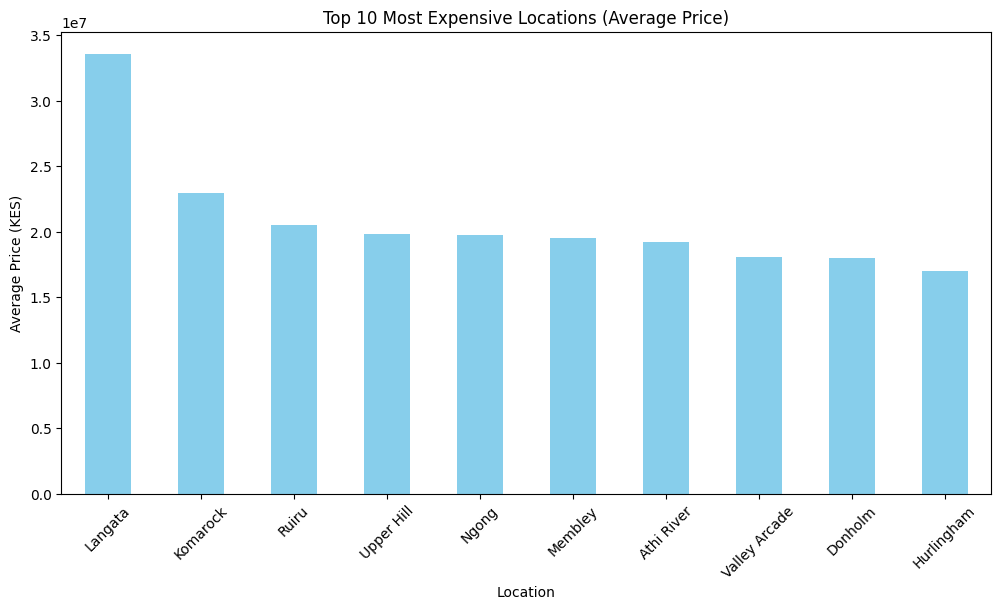

Top 5 Most Expensive Locations:
Location
Langata       3.356667e+07
Komarock      2.300000e+07
Ruiru         2.050000e+07
Upper Hill    1.980000e+07
Ngong         1.972402e+07
Name: Price (KES), dtype: float64


In [3]:
# Calculate average price by location and sort in descending order
location_prices = df.groupby('Location')['Price (KES)'].mean().sort_values(ascending=False)

# Plot the top 10 most expensive locations using a bar chart
plt.figure(figsize=(12, 6)) # Set figure size
location_prices.head(10).plot(kind='bar', color='skyblue') # Plot top 10
plt.title('Top 10 Most Expensive Locations (Average Price)') # Add title
plt.ylabel('Average Price (KES)') # Label y-axis
plt.xticks(rotation=45) # Rotate x-axis labels for readability
plt.show() # Display the plot

# Print the top 5 most expensive locations for quick reference
print("Top 5 Most Expensive Locations:")
print(location_prices.head(5))

### 1.2 How strongly does size affect price?

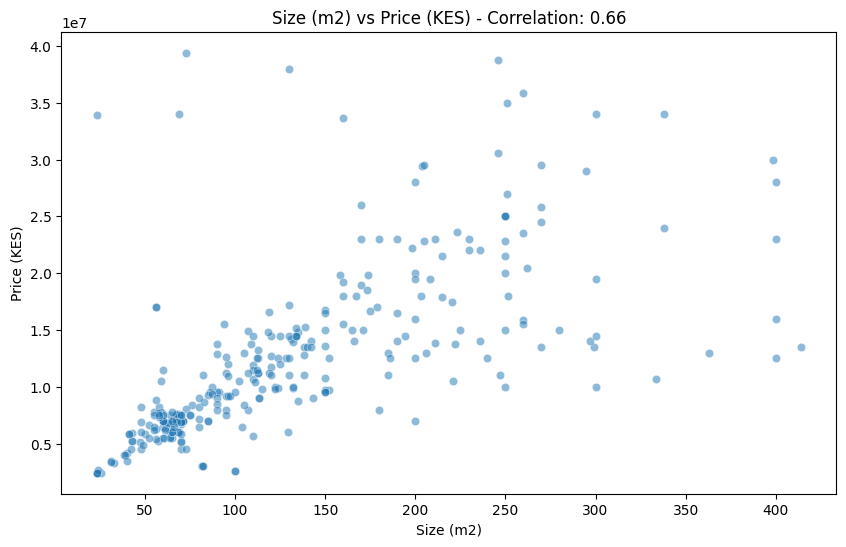

The correlation between size and price is 0.66.


In [4]:
# Calculate Pearson correlation between size and price
correlation = df['Size (m2)'].corr(df['Price (KES)'])

# Create a scatter plot to visualize the relationship between Size and Price
plt.figure(figsize=(10, 6)) # Set figure size
sns.scatterplot(data=df, x='Size (m2)', y='Price (KES)', alpha=0.5) # Plot scatter with transparency
plt.title(f'Size (m2) vs Price (KES) - Correlation: {correlation:.2f}') # Add title with correlation value
plt.show() # Display the plot

# Print the correlation coefficient
print(f"The correlation between size and price is {correlation:.2f}.")

### 1.3 Which amenities increase value?

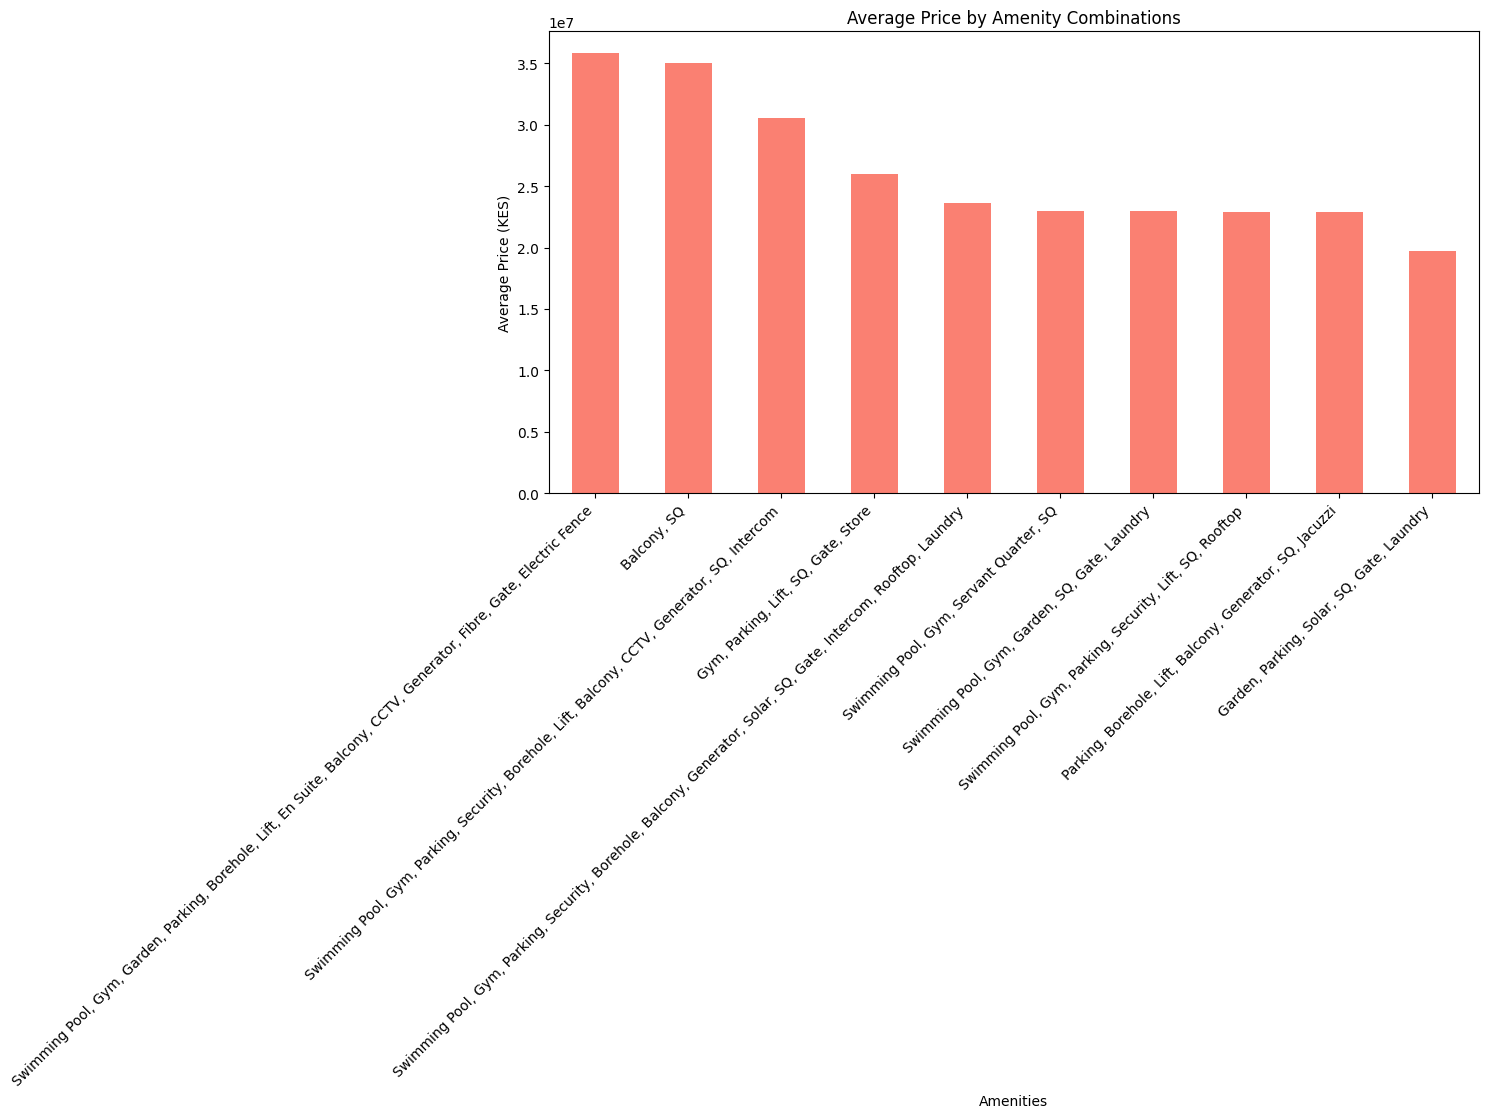

Top 5 Amenities associated with highest prices:
Amenities
Swimming Pool, Gym, Garden, Parking, Borehole, Lift, En Suite, Balcony, CCTV, Generator, Fibre, Gate, Electric Fence    3.579215e+07
Balcony, SQ                                                                                                             3.500000e+07
Swimming Pool, Gym, Parking, Security, Borehole, Lift, Balcony, CCTV, Generator, SQ, Intercom                           3.056904e+07
Gym, Parking, Lift, SQ, Gate, Store                                                                                     2.600000e+07
Swimming Pool, Gym, Parking, Security, Borehole, Balcony, Generator, Solar, SQ, Gate, Intercom, Rooftop, Laundry        2.366092e+07
Name: Price (KES), dtype: float64


In [5]:
# Group by the 'Amenities' column and calculate the mean price
amenity_prices = df.groupby('Amenities')['Price (KES)'].mean().sort_values(ascending=False)

# Plot the top 10 amenity combinations associated with the highest average prices
plt.figure(figsize=(12, 6)) # Set figure size
amenity_prices.head(10).plot(kind='bar', color='salmon') # Plot top 10
plt.title('Average Price by Amenity Combinations') # Add title
plt.ylabel('Average Price (KES)') # Label y-axis
plt.xticks(rotation=45, ha='right') # Rotate and align x-axis labels
plt.show() # Display the plot

# Print the top 5 amenity combinations for quick reference
print("Top 5 Amenities associated with highest prices:")
print(amenity_prices.head(5))

## 2. Modeling

### 2.1 Heuristic Baseline
A simple heuristic: Predict the price based on the average price per square meter across the entire dataset.

In [6]:
# Calculate the global average price per square meter
avg_price_per_m2 = df['Price (KES)'].sum() / df['Size (m2)'].sum()

# Generate heuristic predictions: Size * global average price per m2
df['Heuristic_Pred'] = df['Size (m2)'] * avg_price_per_m2

# Calculate evaluation metrics for the heuristic baseline
h_mae = mean_absolute_error(df['Price (KES)'], df['Heuristic_Pred']) # Mean Absolute Error
h_rmse = np.sqrt(mean_squared_error(df['Price (KES)'], df['Heuristic_Pred'])) # Root Mean Squared Error
h_r2 = r2_score(df['Price (KES)'], df['Heuristic_Pred']) # R-squared score

# Print the performance of the heuristic baseline
print("Heuristic Baseline Performance:")
print(f"MAE: {h_mae:,.2f} KES")
print(f"RMSE: {h_rmse:,.2f} KES")
print(f"R-squared: {h_r2:.4f}")

Heuristic Baseline Performance:
MAE: 3,569,457.40 KES
RMSE: 6,301,398.19 KES
R-squared: 0.2912


### 2.2 Linear Regression Baseline

In [7]:
# Select numerical features for the baseline model
features = ['Bedrooms', 'Bathrooms', 'Size (m2)', 'distance_to_cbd_km', 'amenity_score']
X = df[features] # Feature matrix
y = df['Price (KES)'] # Target variable

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

# Use the trained model to make predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics for the Linear Regression model
mae = mean_absolute_error(y_test, y_pred) # Mean Absolute Error
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # Root Mean Squared Error
r2 = r2_score(y_test, y_pred) # R-squared score

# Print the performance of the Linear Regression baseline
print("Linear Regression Baseline Performance:")
print(f"MAE: {mae:,.2f} KES")
print(f"RMSE: {rmse:,.2f} KES")
print(f"R-squared: {r2:.4f}")

Linear Regression Baseline Performance:
MAE: 3,074,251.50 KES
RMSE: 5,133,411.97 KES
R-squared: 0.5987


## 3. Summary of Results

### Interpretation of MAE
The Mean Absolute Error (MAE) represents the average magnitude of the errors in a set of predictions, without considering their direction. 

**For our Linear Regression model:**
On average, our predictions are off by **3,074,251.50 KES**.

4. A tiny peak into RandomForest

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306 entries, 0 to 305
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Location                306 non-null    object 
 1   Property Type           306 non-null    object 
 2   Bedrooms                306 non-null    int64  
 3   Bathrooms               306 non-null    int64  
 4   Size (m2)               306 non-null    float64
 5   Amenities               306 non-null    object 
 6   Price (KES)             306 non-null    float64
 7   price_per_sqft          306 non-null    float64
 8   distance_to_cbd_km      306 non-null    float64
 9   amenity_score           306 non-null    float64
 10  total_rooms             306 non-null    int64  
 11  room_density            306 non-null    float64
 12  bathroom_bedroom_ratio  306 non-null    float64
 13  is_luxury               306 non-null    int64  
 14  property_category       306 non-null    ob

In [10]:
from sklearn.ensemble import RandomForestRegressor

In [14]:
# Select numerical features for the baseline model
features = ['Bedrooms', 'Bathrooms', 'Size (m2)', 'distance_to_cbd_km', 'amenity_score'
           ,'price_per_sqft', 'total_rooms','room_density','bathroom_bedroom_ratio','is_luxury']
X = df[features] # Feature matrix
y = df['Price (KES)'] # Target variable

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Linear Regression model
model = RandomForestRegressor()

# Train the model using the training data
model.fit(X_train, y_train)

# Use the trained model to make predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics for the Linear Regression model
mae = mean_absolute_error(y_test, y_pred) # Mean Absolute Error
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # Root Mean Squared Error
r2 = r2_score(y_test, y_pred) # R-squared score

# Print the performance of the Linear Regression baseline
print("Random ForestRegression Baseline Performance:")
print(f"MAE: {mae:,.2f} KES")
print(f"RMSE: {rmse:,.2f} KES")
print(f"R-squared: {r2:.4f}")

Random ForestRegression Baseline Performance:
MAE: 1,342,603.55 KES
RMSE: 3,365,948.60 KES
R-squared: 0.8275
